# MIG Quant Competition — Strategy Development

This notebook shows you how to:
1. Build and iterate on a strategy using the `get_actions` interface.
2. Test with backtester locally to get PnL, Sharpe, and Max Drawdown.
3. Inspect portfolio behaviour before submitting.

### Creating an Algorithm

Guides / other resources:

- [Kaggle asset trading guide](https://www.kaggle.com/code/shtrausslearning/building-an-asset-trading-strategy)
- [Kaggle simple momentum trader](https://www.kaggle.com/code/amirmotefaker/algorithmic-trading)
- [Kaggle Decision Trees for trading](https://www.kaggle.com/code/sndorburian/decision-tree-for-trading-using-python)

Less Relevant:
- [Kaggle Features Hierarchical clustering](https://www.kaggle.com/code/apolitano20/jane-street-features-hierarchical-clustering/notebook)
- [Optiver intro to financial concepts](https://www.kaggle.com/code/jiashenliu/introduction-to-financial-concepts-and-data)

In general there are a few steps to creating a trading algorithm:
1. **Understanding and Exploring your data** — get to know what data you're given and find statistical or other properties about it
2. **Feature/signal creation** — create signals from the data (rolling average, correlation, etc.) — this is where most of the secret sauce is
3. **Feature selection + model creation** — decide what features to include and whether to use a machine-learning or rules-based model
4. **Testing** — test your model to see how it performed; avoid "data leakage" (trading on a day using future information)

Iterate steps 2–4 to refine and improve your model!

### Different types of models
- ML type (supervised vs unsupervised)
- Decision Trees (rule-based ML approach) — e.g. XGBoost
- Rule-based (hand-coded)

## Algorithm Input and Output

The algorithm takes in data similar to `dev_data_30.csv`.

The output should be a **NumPy array of size S×D** where S = number of stocks (alphabetical order) and D = number of days.  
For example, with stocks A and B over 5 days:

```python
[[0, 3, 0, -1, -5],   # trades for stock A
 [1, 5, 0, -6,  3]]  # trades for stock B
```

Positive values = buy shares; negative values = sell or short shares.

To save your output array:

```python
import numpy as np

output = np.array([[...],
                   [...],
                   ...])

np.save('output.npy', output)
```

In [50]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, '..')
from backtester import Backtester

plt.style.use('dark_background')
print('Imports OK')

Imports OK


## 1. Load data and build the prices matrix

In [ ]:
df = pd.read_csv('../dev_data_30.csv', parse_dates=['Date'], date_format='%m/%d/%y', thousands=',')

prices_df = df.pivot(index='Ticker', columns='Date', values='Open').sort_index()
prices_df = prices_df.ffill(axis=1).dropna(axis=1)

prices = prices_df.values   # shape: (num_stocks, num_days)
dates  = prices_df.columns  # DatetimeIndex
tickers = prices_df.index.tolist()

print('Prices matrix:', prices.shape)
print('Tickers:', tickers)

# Multi-index view for exploration (complement to the pivot above)
df_explore = pd.read_csv('../dev_data_30.csv', parse_dates=['Date'], date_format='%m/%d/%y', thousands=',')
df_explore.set_index(["Ticker", "Date"], inplace=True)

# Show the MultiIndex structure
df_explore.index

Prices matrix: (10, 1006)
Tickers: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


MultiIndex([('A', '3/15/17'),
            ('A', '3/16/17'),
            ('A', '3/17/17'),
            ('A', '3/20/17'),
            ('A', '3/21/17'),
            ('A', '3/22/17'),
            ('A', '3/23/17'),
            ('A', '3/24/17'),
            ('A', '3/27/17'),
            ('A', '3/28/17'),
            ...
            ('J',  '3/1/21'),
            ('J',  '3/2/21'),
            ('J',  '3/3/21'),
            ('J',  '3/4/21'),
            ('J',  '3/5/21'),
            ('J',  '3/8/21'),
            ('J',  '3/9/21'),
            ('J', '3/10/21'),
            ('J', '3/11/21'),
            ('J', '3/12/21')],
           names=['Ticker', 'Date'], length=10060)

## 1.5 Explore the raw DataFrame

Before building a strategy, it helps to understand the raw DataFrame structure. `data_exploration.ipynb` walkthrough.

## 2. The Backtester

This is a copy of the server-side `Backtester` class so you can run it locally.

In [52]:
def backtest(strategy_fn, prices, cash=25_000):
    """Run strategy_fn on prices and return port_values + pnl."""
    actions = strategy_fn(prices)
    bt = Backtester(prices, actions, cash=cash)
    port_values, pnl = bt.eval_actions()
    if port_values is None:
        return None
    return {
        'port_values': np.array(port_values),
        'pnl': pnl,
    }

print('Backtester ready')

Backtester ready


## 3. Write your strategy

Edit the `get_actions` function below. The interface is identical to what the server expects.

In [53]:
# NOTE: that we don't use future price data to make trades in the past!
# This is to prevent "look-ahead bias" which is a common mistake in algorithmic trading, and will result in a score of 0 in the competition
# TODO: have a way to track your positions (short/long positions), your cash balance, adn your portfolio value
# recall the restrictions in the docs that you cannot buy a share if you don't have enough cash
# and you can't have your debt exceed the value of your cash and long positions
# "debt" in our case is really just the negative value of our short positions


def get_actions(prices: np.ndarray) -> np.ndarray:
    """
    5 / 20-day moving-average crossover — starter template.

    prices : np.ndarray  shape (num_stocks, num_days)  Open price
    returns: np.ndarray  shape (num_stocks, num_days)  shares to trade
    """
    num_stocks, num_days = prices.shape
    actions = np.zeros_like(prices)

    short_window, long_window = 5, 20

    for i in range(num_stocks):
        position = 0
        for t in range(long_window, num_days):
            short_ma = prices[i, t - short_window : t].mean()
            long_ma  = prices[i, t - long_window  : t].mean()

            if short_ma > long_ma and position == 0:
                actions[i, t] = 1
                position = 1
            elif short_ma <= long_ma and position == 1:
                actions[i, t] = -1
                position = 0

    return actions

## 4. Run the backtest

In [54]:
results = backtest(get_actions, prices)

if results:
    print(f"PnL: ${results['pnl']:,.2f}")
else:
    print('Backtest failed — check your strategy for errors.')

Final portfolio value: 22137.45
PnL: -2862.55
PnL: $-2,862.55


## 5. Visualise portfolio value

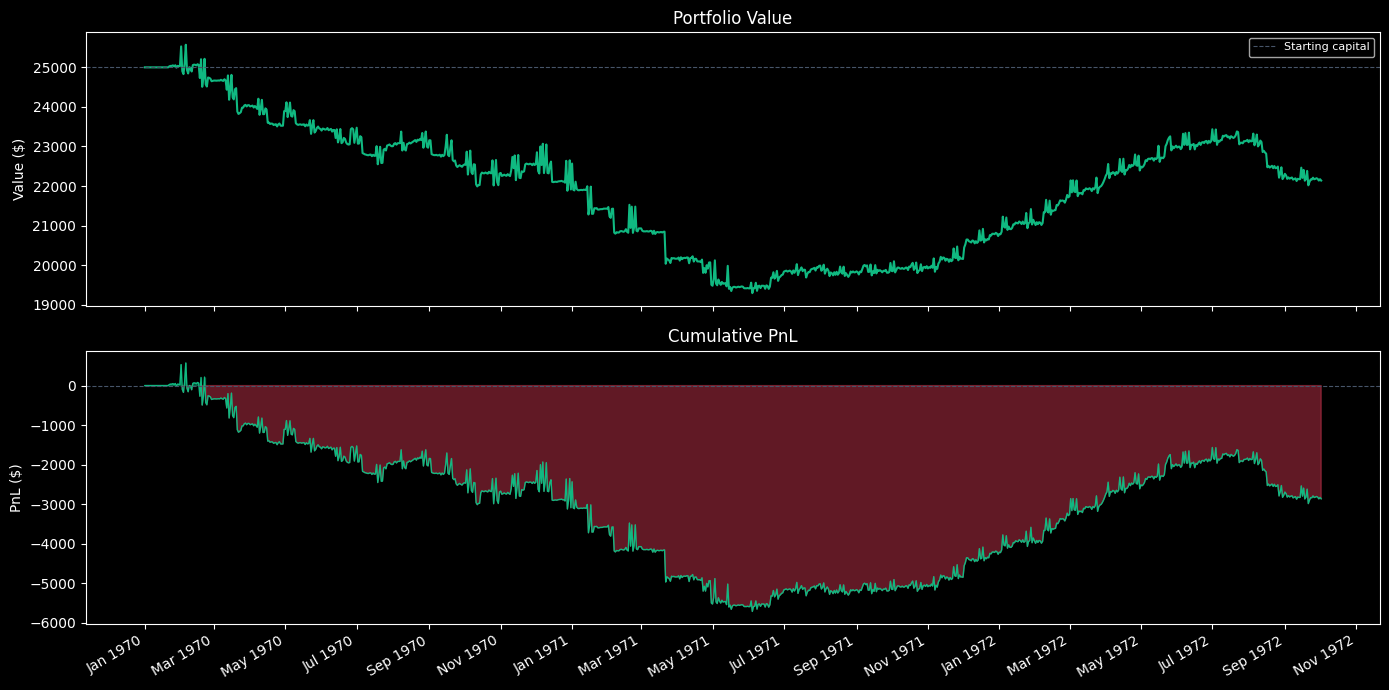

In [55]:
if results:
    pv   = results['port_values']
    pnl  = pv - 25_000

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Portfolio value
    axes[0].plot(dates, pv, color='#10b981', linewidth=1.5)
    axes[0].axhline(25_000, color='#475569', linewidth=0.8, linestyle='--', label='Starting capital')
    axes[0].set_title('Portfolio Value')
    axes[0].set_ylabel('Value ($)')
    axes[0].legend(fontsize=8)

    # Cumulative PnL
    pos_mask = pnl >= 0
    axes[1].fill_between(dates, pnl, where=pos_mask,  color='#10b981', alpha=0.4)
    axes[1].fill_between(dates, pnl, where=~pos_mask, color='#f43f5e', alpha=0.4)
    axes[1].plot(dates, pnl, color='#10b981', linewidth=1)
    axes[1].axhline(0, color='#475569', linewidth=0.8, linestyle='--')
    axes[1].set_title('Cumulative PnL')
    axes[1].set_ylabel('PnL ($)')
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

## 7. Per-stock contribution to PnL

Which stocks drove your returns?

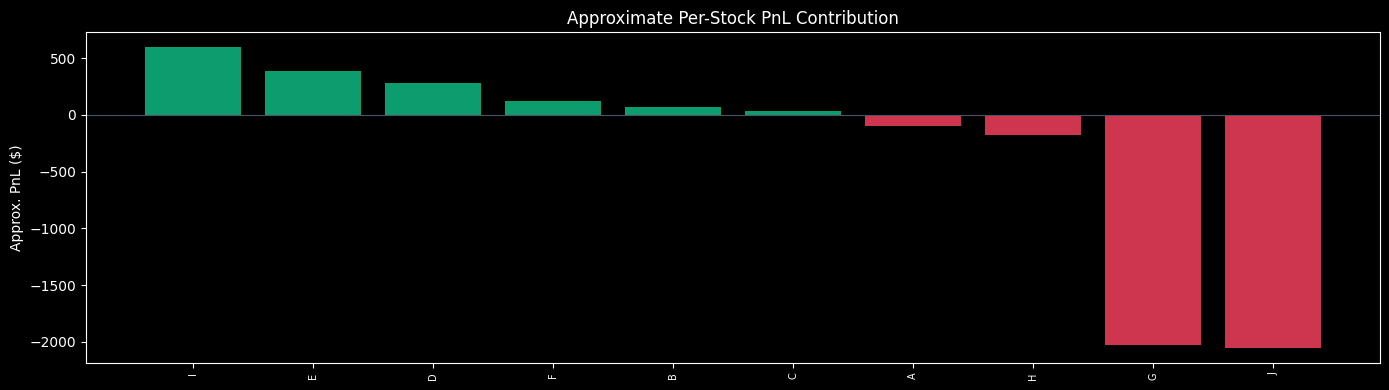

In [56]:
# Rough per-stock PnL estimate: sum of (action × price × sign)
actions_out = get_actions(prices)
actions_rounded = np.round(actions_out).astype(int)

# Approximate realised P&L per stock (ignores FIFO short accounting)
trade_pnl = np.zeros(len(tickers))
for s in range(len(tickers)):
    trade_pnl[s] = -np.sum(actions_rounded[s] * prices[s])

# Add mark-to-market of any remaining positions
final_position = actions_rounded.sum(axis=1)
mtm = final_position * prices[:, -1]
approx_pnl = trade_pnl + mtm

pnl_df = pd.Series(approx_pnl, index=tickers).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#10b981' if v >= 0 else '#f43f5e' for v in pnl_df.values]
ax.bar(pnl_df.index, pnl_df.values, color=colors, alpha=0.85)
ax.axhline(0, color='#475569', linewidth=0.8)
ax.set_title('Approximate Per-Stock PnL Contribution')
ax.set_ylabel('Approx. PnL ($)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 8. Improve & iterate

Some ideas to try:

- **Change the MA windows** — try 10/50, or EMA instead of SMA.
- **Add position sizing** — trade more shares when the signal is stronger.
- **Use RSI or Bollinger Bands** via `ta-lib`.
- **Cross-sectional momentum** — rank stocks by recent return and go long top N, short bottom N.
- **Mean reversion** — trade against recent moves instead of following them.
- **Risk controls** — cap total exposure, stop-out losing positions.

Once you are happy with local results, copy your `get_actions` function into a `.py` file and submit on the **Submit** page.

In [57]:
def compare_strategies(strategies: dict, prices, cash=25_000):
    """strategies: {name: get_actions_fn}"""
    rows = []
    for name, fn in strategies.items():
        r = backtest(fn, prices, cash=cash)
        rows.append({
            'Strategy': name,
            'PnL ($)': f"{r['pnl']:,.2f}" if r else 'FAILED',
        })
    return pd.DataFrame(rows).set_index('Strategy')


def ma_crossover(short_w, long_w):
    def fn(prices):
        num_stocks, num_days = prices.shape
        actions = np.zeros_like(prices)
        for i in range(num_stocks):
            pos = 0
            for t in range(long_w, num_days):
                sm = prices[i, t - short_w : t].mean()
                lm = prices[i, t - long_w  : t].mean()
                if sm > lm and pos == 0:
                    actions[i, t] = 1; pos = 1
                elif sm <= lm and pos == 1:
                    actions[i, t] = -1; pos = 0
        return actions
    fn.__name__ = f'MA({short_w}/{long_w})'
    return fn


strats = {
    'MA(5/20)':  ma_crossover(5, 20),
    'MA(10/50)': ma_crossover(10, 50),
    'MA(3/10)':  ma_crossover(3, 10),
}

compare_strategies(strats, prices)

Final portfolio value: 22137.45
PnL: -2862.55
Final portfolio value: 27492.65
PnL: 2492.65
Final portfolio value: 40584.47
PnL: 15584.47


,PnL ($)
Strategy,
MA(5/20),"-2,862.55"
MA(10/50),"2,492.65"
MA(3/10),"15,584.47"
